# 07 — Least squares as projection

Notebook 06 introduced least squares as a way to fit the best line when the data points do not sit exactly on one line.

This notebook explains the geometry underneath that idea.

Least squares is a projection problem:

$$
A\mathbf{x}^{*} = \operatorname{proj}_{C(A)}(\mathbf{b})
$$

We will build up to that statement slowly.

The key question is:

> If $A\mathbf{x}$ cannot reach $\mathbf{b}$ exactly, which reachable vector gets closest?


## Imports and plotting helpers

The examples use NumPy for the calculations and Matplotlib for the geometry.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def print_vector(name, vector):
    # Print a vector compactly for notebook examples.
    values = ", ".join(f"{value: .3f}" for value in vector)
    print(f"{name} = [{values}]")


def draw_vector_3d(ax, vector, label, *, start=None, linewidth=2, alpha=1.0):
    # Draw a 3D vector from start to start + vector.
    if start is None:
        start = np.zeros(3)

    vector = np.asarray(vector)
    start = np.asarray(start)

    ax.quiver(
        start[0], start[1], start[2],
        vector[0], vector[1], vector[2],
        arrow_length_ratio=0.08,
        linewidth=linewidth,
        alpha=alpha,
    )

    end = start + vector
    ax.text(end[0], end[1], end[2], label, fontsize=11)


def setup_3d_axis(ax, title):
    # Use shared 3D axis settings for the projection plot.
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_xlim(-0.5, 4.2)
    ax.set_ylim(-0.5, 3.2)
    ax.set_zlim(-0.2, 4.5)
    ax.view_init(elev=22, azim=-62)


## Projection recap: reachable part plus leftover

In the earlier projection notebook, projection meant dropping one vector onto another vector.

Here the idea is slightly broader. We can project onto a whole space, not just onto one direction.

Projection splits a target vector into two parts:

- the part inside the space we are allowed to use
- the leftover part at right angles to that space

In this notebook, the space we are allowed to use will be the column space of a matrix.

The decomposition looks like this:

$$
\mathbf{b} = \operatorname{proj}_{S}(\mathbf{b}) + \mathbf{r}
$$

where $\mathbf{r}$ is perpendicular to the space $S$.


## A matrix as a reachable-vector machine

Start with this matrix:

$$
A =
\begin{bmatrix}
1 & 0 \\
0 & 1 \\
1 & 1
\end{bmatrix}
$$

It has two columns:

$$
\mathbf{a}_1 =
\begin{bmatrix}
1 \\
0 \\
1
\end{bmatrix}
\qquad
\mathbf{a}_2 =
\begin{bmatrix}
0 \\
1 \\
1
\end{bmatrix}
$$

Multiplying by $A$ builds a vector from those columns:

$$
A
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
x_1\mathbf{a}_1 + x_2\mathbf{a}_2
$$

So $A\mathbf{x}$ can only reach combinations of the columns of $A$.


In [3]:
A = np.array([
    [1, 0],
    [0, 1],
    [1, 1],
])

a1 = A[:, 0]
a2 = A[:, 1]

print_vector("a1", a1)
print_vector("a2", a2)


a1 = [ 1.000,  0.000,  1.000]
a2 = [ 0.000,  1.000,  1.000]


For example, choose:

$$
\mathbf{x} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
$$

Then $A\mathbf{x}$ is a reachable vector because it is a combination of the columns of $A$.


In [4]:
x_trial = np.array([2, 1])
reachable_trial = A @ x_trial

print_vector("x_trial", x_trial)
print_vector("A @ x_trial", reachable_trial)


x_trial = [ 2.000,  1.000]
A @ x_trial = [ 2.000,  1.000,  3.000]


## Column space

The column space of $A$, written $C(A)$, is the set of every vector that $A\mathbf{x}$ can reach.

For this matrix, $A\mathbf{x}$ always has this form:

$$
A
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
\begin{bmatrix}
x_1 \\
x_2 \\
x_1 + x_2
\end{bmatrix}
$$

So the reachable vectors all lie on a plane in 3D.

That plane is the column space of $A$.


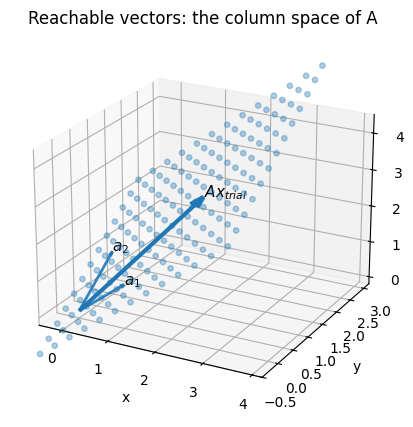

In [5]:
# Generate a small grid of reachable vectors.
x1_values = np.linspace(-0.5, 3.5, 13)
x2_values = np.linspace(-0.5, 2.5, 13)

plane_points = []
for x1 in x1_values:
    for x2 in x2_values:
        plane_points.append(A @ np.array([x1, x2]))

plane_points = np.array(plane_points)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
setup_3d_axis(ax, "Reachable vectors: the column space of A")

ax.scatter(
    plane_points[:, 0],
    plane_points[:, 1],
    plane_points[:, 2],
    alpha=0.35,
    s=15,
)

draw_vector_3d(ax, a1, "$a_1$", alpha=0.9)
draw_vector_3d(ax, a2, "$a_2$", alpha=0.9)
draw_vector_3d(ax, reachable_trial, "$A x_{trial}$", linewidth=3)

plt.show()


The specific grid of dots is not important.

The important idea is that the columns of $A$ span a plane. Any vector on that plane is reachable as $A\mathbf{x}$.


## When there is no exact solution

Now suppose the target vector is:

$$
\mathbf{b} =
\begin{bmatrix}
2 \\
1 \\
4
\end{bmatrix}
$$

We want to solve:

$$
A\mathbf{x} = \mathbf{b}
$$

But this would require:

$$
x_1 = 2
\qquad
x_2 = 1
\qquad
x_1 + x_2 = 4
$$

The first two equations say $x_1 + x_2 = 3$, but the third equation says $x_1 + x_2 = 4$.

So there is no exact solution.


In [6]:
b = np.array([2, 1, 4])

print_vector("b", b)
print_vector("A @ x_trial", reachable_trial)
print_vector("b - A @ x_trial", b - reachable_trial)


b = [ 2.000,  1.000,  4.000]
A @ x_trial = [ 2.000,  1.000,  3.000]
b - A @ x_trial = [ 0.000,  0.000,  1.000]


The residual is the miss, or leftover:

$$
\mathbf{r} = \mathbf{b} - A\mathbf{x}
$$

If $A\mathbf{x}$ cannot equal $\mathbf{b}$ exactly, we can still ask for the reachable vector with the smallest residual.


## Trying candidate reachable vectors

This is the same kind of thinking as the candidate line in Notebook 06.

There, a candidate line produced candidate predictions. Here, a candidate $\mathbf{x}$ produces a candidate reachable vector $A\mathbf{x}$.

We can compare candidates by measuring the length of their residuals.


In [7]:
candidate_xs = [
    np.array([2.0, 1.0]),
    np.array([2.5, 1.5]),
    np.array([7 / 3, 4 / 3]),
]

print("candidate x        A @ x              residual           residual length")
print("-" * 78)

for candidate_x in candidate_xs:
    candidate_reachable = A @ candidate_x
    candidate_residual = b - candidate_reachable
    residual_length = np.linalg.norm(candidate_residual)

    x_text = np.array2string(candidate_x, precision=3, floatmode="fixed")
    reachable_text = np.array2string(candidate_reachable, precision=3, floatmode="fixed")
    residual_text = np.array2string(candidate_residual, precision=3, floatmode="fixed")

    print(f"{x_text:18} {reachable_text:18} {residual_text:18} {residual_length: .3f}")


candidate x        A @ x              residual           residual length
------------------------------------------------------------------------------
[2.000 1.000]      [2.000 1.000 3.000] [0.000 0.000 1.000]  1.000
[2.500 1.500]      [2.500 1.500 4.000] [-0.500 -0.500  0.000]  0.707
[2.333 1.333]      [2.333 1.333 3.667] [-0.333 -0.333  0.333]  0.577


The last candidate is not magic. It is the least-squares answer, written as exact fractions so that we can see the values clearly.

Least squares chooses the reachable vector whose residual is as short as possible.


## Least squares changes the question

If the exact equation has no solution, least squares changes the question from:

$$
A\mathbf{x} = \mathbf{b}
$$

to:

$$
\text{which } A\mathbf{x} \text{ is closest to } \mathbf{b}\text{?}
$$

In NumPy, `np.linalg.lstsq` finds the value of $\mathbf{x}$ that gives the closest reachable vector.


In [8]:
x_star, residuals_sum, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

projection = A @ x_star
residual = b - projection

print_vector("x_star", x_star)
print_vector("projection = A @ x_star", projection)
print_vector("residual = b - projection", residual)
print(f"residual length = {np.linalg.norm(residual):.3f}")


x_star = [ 2.333,  1.333]
projection = A @ x_star = [ 2.333,  1.333,  3.667]
residual = b - projection = [-0.333, -0.333,  0.333]
residual length = 0.577


The vector `projection` is important:

$$
A\mathbf{x}^{*}
$$

It is the closest reachable vector to $\mathbf{b}$.

That is why this is a projection problem.


## Why the closest reachable vector is a projection

For a projection, the leftover part is perpendicular to the space we projected onto.

Here, the residual is:

$$
\mathbf{r} = \mathbf{b} - A\mathbf{x}^{*}
$$

The residual should be perpendicular to every column of $A$.

That means:

$$
\mathbf{a}_1 \cdot \mathbf{r} = 0
\qquad
\mathbf{a}_2 \cdot \mathbf{r} = 0
$$


In [9]:
print(f"a1 dot residual = {np.dot(a1, residual): .12f}")
print(f"a2 dot residual = {np.dot(a2, residual): .12f}")


a1 dot residual =  0.000000000000
a2 dot residual = -0.000000000000


Those values are zero, allowing for tiny floating-point round-off.

So the closest reachable vector is the projection of $\mathbf{b}$ onto the column space of $A$.


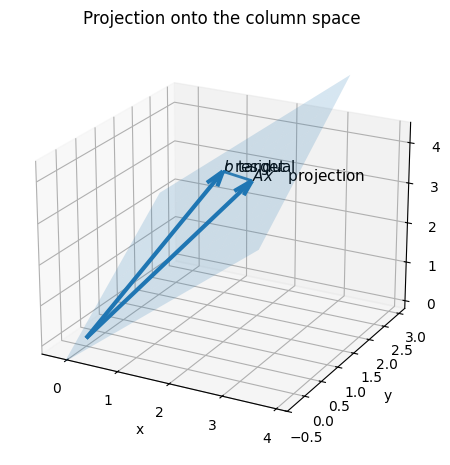

In [10]:
# Plot the column-space plane, the target vector b,
# the closest reachable vector, and the residual.
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
setup_3d_axis(ax, "Projection onto the column space")

# Draw a translucent surface for the column space plane.
s1 = np.linspace(-0.25, 3.5, 12)
s2 = np.linspace(-0.25, 2.4, 12)
S1, S2 = np.meshgrid(s1, s2)
Z = S1 + S2
ax.plot_surface(S1, S2, Z, alpha=0.18, linewidth=0)

# Show the target, projection, and residual.
draw_vector_3d(ax, b, "$b$ target", linewidth=3)
draw_vector_3d(ax, projection, "$A x^*$ projection", linewidth=3)
draw_vector_3d(ax, residual, "$r$ residual", start=projection, linewidth=2, alpha=0.9)

# Add a faint guide from the origin to the residual endpoint.
ax.plot(
    [projection[0], b[0]],
    [projection[1], b[1]],
    [projection[2], b[2]],
    linestyle="--",
    linewidth=1,
    alpha=0.6,
)

plt.show()


This plot is the main geometric idea.

- The plane is the column space of $A$.
- The vector $\mathbf{b}$ is the target we cannot reach exactly.
- The vector $A\mathbf{x}^{*}$ is the closest reachable vector.
- The residual $\mathbf{r}$ is perpendicular to the plane.

So least squares has projected $\mathbf{b}$ onto the column space of $A$.


## The normal equations

The projection picture also explains the normal equations.

The residual is perpendicular to every column of $A$. In matrix form, that says:

$$
A^T(\mathbf{b} - A\mathbf{x}^{*}) = \mathbf{0}
$$

Expanding the brackets gives:

$$
A^T\mathbf{b} - A^T A\mathbf{x}^{*} = \mathbf{0}
$$

So:

$$
A^T A\mathbf{x}^{*} = A^T\mathbf{b}
$$

These are the normal equations.


In [11]:
normal_left = A.T @ A
normal_right = A.T @ b
x_from_normal_equations = np.linalg.solve(normal_left, normal_right)

print("A.T @ A:")
print(normal_left)
print()
print_vector("A.T @ b", normal_right)
print_vector("x_from_normal_equations", x_from_normal_equations)


A.T @ A:
[[2 1]
 [1 2]]

A.T @ b = [ 6.000,  5.000]
x_from_normal_equations = [ 2.333,  1.333]


The normal equations produce the same $\mathbf{x}^{*}$ in this example.

They are useful for understanding the maths. In numerical code, `np.linalg.lstsq` is usually the better habit because it is designed for least-squares problems.

Also, solving the normal equations directly assumes that $A^T A$ can be solved cleanly. That is true in this small example, but not something to assume blindly in every problem.


## Connecting this back to line fitting

In Notebook 06, the fitted line had this form:

$$
y = mx + c
$$

For several observed data points, we wrote that as a matrix equation:

$$
X\boldsymbol{\beta} \approx \mathbf{y}
$$

where:

$$
\boldsymbol{\beta} =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

The design matrix $X$ works just like the matrix $A$ in this notebook.

The possible prediction vectors are the vectors in the column space of $X$.


In [12]:
# Observed data from the line-fitting example.
x_data = np.array([1, 2, 3, 4])
y_data = np.array([2.0, 2.5, 3.5, 3.8])

# The design matrix for y = mx + c.
X = np.column_stack([x_data, np.ones_like(x_data)])

beta_star, *_ = np.linalg.lstsq(X, y_data, rcond=None)
y_projected = X @ beta_star
line_residual = y_data - y_projected

print_vector("beta_star = [m, c]", beta_star)
print_vector("y_projected = X @ beta_star", y_projected)
print_vector("line_residual = y_data - y_projected", line_residual)
print_vector("X.T @ line_residual", X.T @ line_residual)


beta_star = [m, c] = [ 0.640,  1.350]
y_projected = X @ beta_star = [ 1.990,  2.630,  3.270,  3.910]
line_residual = y_data - y_projected = [ 0.010, -0.130,  0.230, -0.110]
X.T @ line_residual = [ 0.000,  0.000]


For line fitting, the projection statement is:

$$
X\boldsymbol{\beta}^{*} = \operatorname{proj}_{C(X)}(\mathbf{y})
$$

The fitted values $X\boldsymbol{\beta}^{*}$ are the closest reachable prediction vector to the observed data vector $\mathbf{y}$.


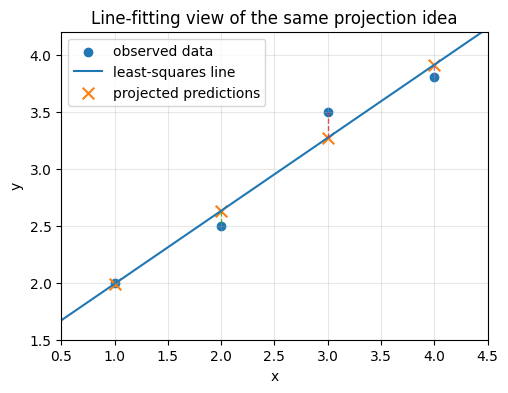

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 4))

line_x = np.linspace(0.5, 4.5, 100)
line_y = beta_star[0] * line_x + beta_star[1]

ax.scatter(x_data, y_data, label="observed data")
ax.plot(line_x, line_y, label="least-squares line")
ax.scatter(x_data, y_projected, marker="x", s=70, label="projected predictions")

for x_i, y_i, y_hat_i in zip(x_data, y_data, y_projected):
    ax.plot([x_i, x_i], [y_hat_i, y_i], linestyle="--", linewidth=1, alpha=0.8)

ax.set_title("Line-fitting view of the same projection idea")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0.5, 4.5)
ax.set_ylim(1.5, 4.2)
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()


This plot shows the familiar line-fitting view: points, fitted line, fitted predictions, and residuals.

But the projection itself is happening in prediction-vector space.

Least squares finds the closest prediction vector that the design matrix can reach.


## Summary

A matrix $A$ can be read as a machine that builds combinations of its columns:

$$
A\mathbf{x} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2 + \cdots
$$

The set of all reachable vectors $A\mathbf{x}$ is the column space of $A$, written $C(A)$.

When $A\mathbf{x} = \mathbf{b}$ has no exact solution, least squares finds the closest reachable vector:

$$
A\mathbf{x}^{*} = \operatorname{proj}_{C(A)}(\mathbf{b})
$$

The residual is the leftover part:

$$
\mathbf{r} = \mathbf{b} - A\mathbf{x}^{*}
$$

At the least-squares solution, the residual is perpendicular to the column space:

$$
A^T\mathbf{r} = \mathbf{0}
$$

This gives the normal equations:

$$
A^T A\mathbf{x}^{*} = A^T\mathbf{b}
$$

For line fitting, the same idea becomes:

$$
X\boldsymbol{\beta}^{*} = \operatorname{proj}_{C(X)}(\mathbf{y})
$$

So least squares is not only a line-fitting trick. It is a projection onto the space of predictions the model can produce.
